In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Download + Load Spotify Catalog Dataset (≈550K)


- install and import kagglehub
- downloads the Spotify catalog dataset from Kaggle into the Colab cache
- loads the two main tables:
  - songs.csv (song-level audio + metadata)
  - artists.csv (artist-level metadata)
- confirms successful load by printing file list, shapes, and previewing rows



In [72]:
!pip -q install kagglehub

import kagglehub
import os
import pandas as pd

# Download dataset to Colab cache
data_dir = kagglehub.dataset_download("serkantysz/550k-spotify-songs-audio-lyrics-and-genres")
print("Dataset downloaded to:", data_dir)
print("Files:", os.listdir(data_dir))

# Load
songs = pd.read_csv(
    os.path.join(data_dir, "songs.csv"),
    engine="python",
    on_bad_lines="skip"
)

artists = pd.read_csv(
    os.path.join(data_dir, "artists.csv"),
    engine="python",
    on_bad_lines="skip"
)

print("Songs:", songs.shape)
print("Artists:", artists.shape)
songs.head()



Using Colab cache for faster access to the '550k-spotify-songs-audio-lyrics-and-genres' dataset.
Dataset downloaded to: /kaggle/input/550k-spotify-songs-audio-lyrics-and-genres
Files: ['artists.csv', 'songs.csv']
Songs: (550622, 24)
Artists: (71440, 6)


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [73]:
!pip -q install -U kagglehub


In [74]:
import numpy as np
import pandas as pd

audio_feats = [
    "danceability","energy","valence","tempo","loudness",
    "acousticness","speechiness","instrumentalness","liveness","duration_ms"
]

df = songs[audio_feats + ["year","genre","popularity","name","artists"]].copy()

# drop missing
df = df.dropna(subset=audio_feats)

# filter duration (0–15 min) to match your team’s EDA
duration_min = df["duration_ms"] / 60000
df = df[(duration_min >= 0) & (duration_min <= 15)].copy()

print("Rows for clustering:", df.shape)
df.head()


Rows for clustering: (549829, 15)


,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,liveness,duration_ms,year,genre,popularity,name,artists
0,0.415,0.605,0.193,100.059,-11.157,0.001160,0.0575,0.838000,0.471,79500,2016,Rock,0,!,"[""HELLYEAH""]"
1,0.788,0.648,0.287,79.998,-9.135,0.900000,0.3150,0.000000,0.176,114000,2019,Hip-Hop,29,!!,"[""Yxngxr1""]"
2,0.171,0.957,0.349,175.317,-5.749,0.000029,0.1490,0.000032,0.330,197400,2002,Rock,0,!!Noble Stabbings!!,"[""Dillinger Four""]"
3,0.823,0.612,0.688,142.959,-7.767,0.168000,0.2480,0.000000,0.109,178533,2018,Hip-Hop,43,!I'll Be Back!,"[""Ril\u00e8s""]"
4,0.729,0.552,0.380,86.103,-8.562,0.183000,0.0650,0.000000,0.131,186197,2018,Hip-Hop,0,!Lost!,"[""Ril\u00e8s""]"


## Create Working Sample for Clustering

To keep the clustering step computationally efficient, we randomly sample **60,000 songs** from the full dataset.

This subset preserves the overall distribution of audio features while enabling faster model selection and iteration.


In [75]:
df_work = df.sample(n=60000, random_state=42).copy()
print("Working sample:", df_work.shape)



Working sample: (60000, 15)


## Standardize Audio Features

Before clustering, all selected audio features are **standardized** so they contribute equally to distance calculations.

This step is critical for K-Means, since features like tempo and loudness operate on very different scales.


In [76]:
from sklearn.preprocessing import StandardScaler

audio_feats = [
    "danceability","energy","valence","tempo","loudness",
    "acousticness","speechiness","instrumentalness","liveness","duration_ms"
]

X = df_work[audio_feats].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape



(60000, 10)

## Evaluate Cluster Counts (k) Using Elbow and Silhouette Metrics

We test multiple values of **k (2–12)** to assess clustering quality.

For each k:
- **Inertia** measures within-cluster compactness (lower is better)
- **Silhouette score** measures how well clusters are separated (higher is better)

These metrics guide selection of an optimal number of clusters that balances interpretability and structure.


In [79]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 13)
inertias = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

print("Done.")


Done.


## Elbow Method Visualization

This plot shows how **inertia** decreases as the number of clusters increases.


We look for a clear “elbow,” where adding more clusters yields diminishing improvements, indicating a reasonable choice for the final number of clusters.


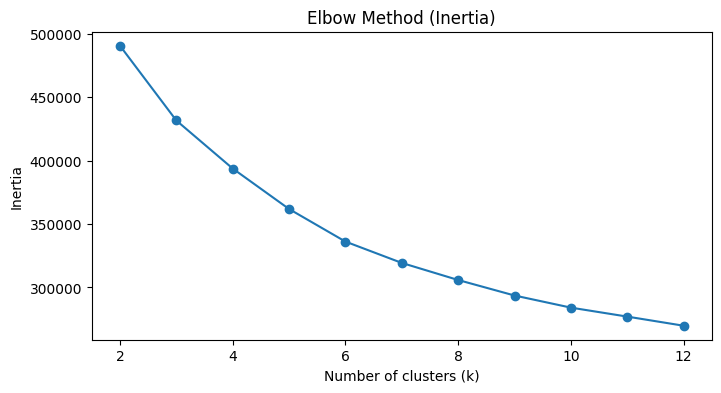

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(list(Ks), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()


## Silhouette Score Visualization

This plot displays the **silhouette score** across different numbers of clusters.


Higher silhouette values indicate better-defined and more clearly separated clusters, helping validate the chosen number of clusters alongside the elbow method.


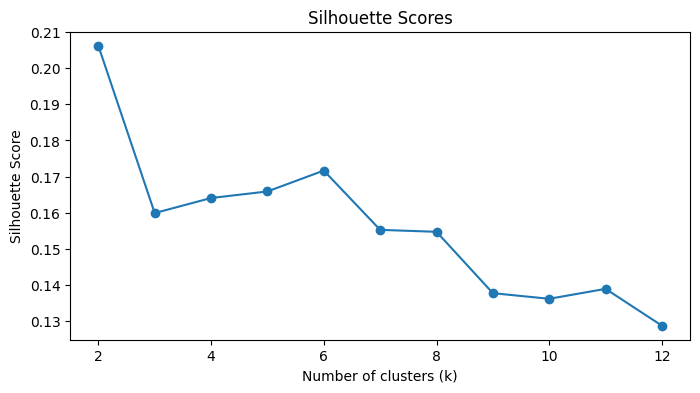

In [81]:
plt.figure(figsize=(8,4))
plt.plot(list(Ks), sil_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


## Silhouette Score Summary by Cluster Count

The printed silhouette scores provide a numeric comparison of cluster quality for each tested value of **k**.

This summary helps confirm the final cluster choice by identifying where separation quality peaks or stabilizes.


In [82]:
for k, s in zip(Ks, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")


k=2: silhouette=0.2062
k=3: silhouette=0.1599
k=4: silhouette=0.1641
k=5: silhouette=0.1659
k=6: silhouette=0.1717
k=7: silhouette=0.1552
k=8: silhouette=0.1547
k=9: silhouette=0.1377
k=10: silhouette=0.1362
k=11: silhouette=0.1389
k=12: silhouette=0.1287


## Fit Final K-Means Model

Using the selected number of clusters (**k = 6**), we train the final K-Means model on the standardized audio features.

Each song in the working sample is assigned a **cluster label**, representing its sound archetype.  
Cluster counts are shown to verify reasonable distribution across groups.


In [83]:
k_final = 6

from sklearn.cluster import KMeans

km = KMeans(n_clusters=k_final, n_init=20, random_state=42)

df_work["cluster"] = km.fit_predict(X_scaled)

print("Cluster counts:")
print(df_work["cluster"].value_counts().sort_index())


Cluster counts:
cluster
0    17483
1    11643
2    16708
3     4103
4     5973
5     4090
Name: count, dtype: int64


## Compute Cluster Audio Profiles (Centroids)

We calculate the **mean value of each audio feature per cluster**, producing a centroid profile for every group.

These centroids represent the **average audio fingerprint** of each cluster and form the basis for interpreting distinct sound archetypes.


In [84]:
cluster_profiles = (
    df_work.groupby("cluster")[audio_feats]
    .mean()
    .round(3)
)

cluster_profiles


,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,liveness,duration_ms
cluster,,,,,,,,,,
0,0.660,0.694,0.680,118.020,-7.314,0.187,0.060,0.029,0.164,218592.983
1,0.492,0.306,0.355,112.846,-12.679,0.710,0.045,0.065,0.165,223345.040
2,0.426,0.833,0.350,135.688,-5.497,0.048,0.079,0.033,0.197,241830.230
3,0.455,0.759,0.442,122.573,-7.448,0.198,0.087,0.072,0.769,272996.818
4,0.440,0.792,0.331,126.091,-7.432,0.087,0.073,0.727,0.203,286924.433
5,0.673,0.677,0.546,118.682,-7.466,0.229,0.347,0.012,0.240,211402.867


## Representative Song Examples per Cluster

For interpretability, we extract a small set of **representative songs** from each cluster.

Within each cluster, songs are ranked by **popularity**, and the top examples are displayed to provide concrete, real-world context for each sound archetype.


In [85]:
cols_show = ["cluster","name","artists","year","genre","popularity"]

top_examples = (
    df_work.sort_values(["cluster","popularity"], ascending=[True, False])
    .groupby("cluster")
    .head(5)[cols_show]
)

top_examples


,cluster,name,artists,year,genre,popularity
148856,0,Feel Good Inc.,"[""Gorillaz"", ""De La Soul""]",2005,Hip-Hop,90
540000,0,You Make It Feel Like Christmas (feat. Blake S...,"[""Gwen Stefani"", ""Blake Shelton""]",2017,Country,88
505558,0,Wake Me Up,"[""Avicii""]",2013,Electronic,86
183076,0,HUMBLE.,"[""Kendrick Lamar""]",2017,Hip-Hop,85
393419,0,Seven Nation Army,"[""The White Stripes""]",2003,Rock,85
143981,1,Fade Into You,"[""Mazzy Star""]",1993,Rock,87
387950,1,Say You Won't Let Go,"[""James Arthur""]",2016,Pop,86
502449,1,Vienna,"[""Billy Joel""]",1977,Rock,85
228766,1,If I Ain't Got You,"[""Alicia Keys""]",2003,R&B,84
182977,1,HIGHEST IN THE ROOM,"[""Travis Scott""]",2019,Hip-Hop,84


## PCA Visualization of Clusters

We project the standardized audio features into **two dimensions using PCA** to visually assess cluster structure.

Each point represents a song, colored by its assigned cluster.  
Clear separation and density patterns indicate that the clustering captures meaningful structure in the audio feature space rather than random noise.


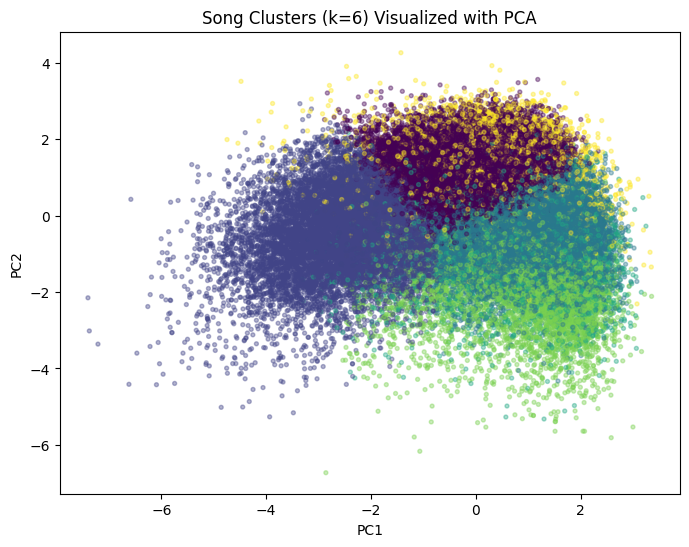

In [86]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X2[:,0], X2[:,1],
            c=df_work["cluster"],
            s=8, alpha=0.4)

plt.title("Song Clusters (k=6) Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [87]:
# --- Z-scored cluster profiles (centroids in standardized space) ---
X_scaled_df = pd.DataFrame(X_scaled, columns=audio_feats, index=df_work.index)
X_scaled_df["cluster"] = df_work["cluster"].values

cluster_profiles_z = (
    X_scaled_df.groupby("cluster")[audio_feats]
    .mean()
    .round(2)
)

cluster_profiles_z

,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,liveness,duration_ms
cluster,,,,,,,,,,
0,0.77,0.10,0.86,-0.17,0.15,-0.18,-0.27,-0.33,-0.31,-0.20
1,-0.20,-1.49,-0.44,-0.35,-1.24,1.52,-0.44,-0.18,-0.30,-0.15
2,-0.59,0.66,-0.46,0.43,0.62,-0.63,-0.06,-0.31,-0.13,0.07
3,-0.42,0.36,-0.09,-0.02,0.11,-0.15,0.02,-0.15,2.77,0.43
4,-0.51,0.50,-0.54,0.10,0.12,-0.51,-0.13,2.57,-0.11,0.59
5,0.85,0.02,0.33,-0.15,0.11,-0.05,2.85,-0.40,0.08,-0.29


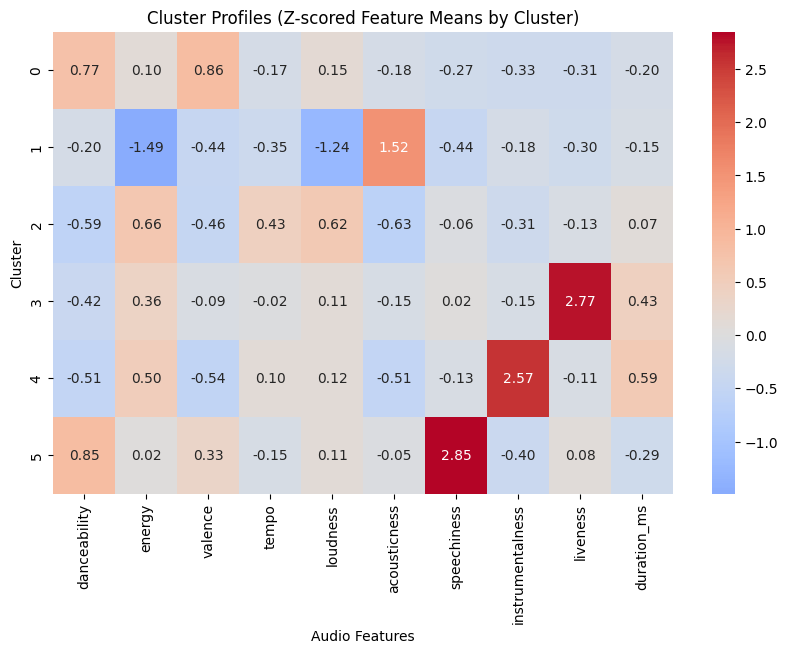

In [88]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profiles_z,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Cluster Profiles (Z-scored Feature Means by Cluster)")
plt.ylabel("Cluster")
plt.xlabel("Audio Features")
plt.show()

In [89]:
df_work["is_hit"] = df_work["popularity"] >= 70
cluster_hit_rate = df_work.groupby("cluster")["is_hit"].mean()

In [90]:
hit_summary = (
    df_work.groupby("cluster")
    .agg(
        total_songs=("is_hit","size"),
        total_hits=("is_hit","sum"),
        hit_rate=("is_hit","mean"),
        avg_popularity=("popularity","mean")
    )
    .sort_values("hit_rate", ascending=False)
)

hit_summary["hit_rate"] = hit_summary["hit_rate"].round(3)
hit_summary["avg_popularity"] = hit_summary["avg_popularity"].round(1)
hit_summary

,total_songs,total_hits,hit_rate,avg_popularity
cluster,,,,
5,4090,36,0.009,21.7
0,17483,130,0.007,19.6
1,11643,63,0.005,16.9
2,16708,75,0.004,17.0
3,4103,11,0.003,15.0
4,5973,12,0.002,14.0


In [91]:
no_hit_clusters = hit_summary[hit_summary["total_hits"] == 0]
no_hit_clusters

,total_songs,total_hits,hit_rate,avg_popularity
cluster,,,,


In [92]:
hit_summary.sort_values("hit_rate", ascending=False)

,total_songs,total_hits,hit_rate,avg_popularity
cluster,,,,
5,4090,36,0.009,21.7
0,17483,130,0.007,19.6
1,11643,63,0.005,16.9
2,16708,75,0.004,17.0
3,4103,11,0.003,15.0
4,5973,12,0.002,14.0


In [93]:
highest = hit_summary.sort_values("hit_rate", ascending=False).head(1)
lowest = hit_summary.sort_values("hit_rate").head(1)

highest, lowest

(         total_songs  total_hits  hit_rate  avg_popularity
 cluster                                                   
 5               4090          36     0.009            21.7,
          total_songs  total_hits  hit_rate  avg_popularity
 cluster                                                   
 4               5973          12     0.002            14.0)

In [94]:
overall_hit_rate = df_work["is_hit"].mean()

hit_summary["enrichment_ratio"] = (
    hit_summary["hit_rate"] / overall_hit_rate
).round(2)

hit_summary.sort_values("enrichment_ratio", ascending=False)

,total_songs,total_hits,hit_rate,avg_popularity,enrichment_ratio
cluster,,,,,
5,4090,36,0.009,21.7,1.65
0,17483,130,0.007,19.6,1.28
1,11643,63,0.005,16.9,0.92
2,16708,75,0.004,17.0,0.73
3,4103,11,0.003,15.0,0.55
4,5973,12,0.002,14.0,0.37


In [95]:
from scipy.stats import chi2_contingency
ct = pd.crosstab(df_work["cluster"], df_work["is_hit"])
chi2, p, dof, expected = chi2_contingency(ct)
p

np.float64(3.8720405475243285e-08)

In [96]:
chi2, p, dof, expected = chi2_contingency(ct)
chi2, dof, p

(np.float64(42.89975490522448), 5, np.float64(3.8720405475243285e-08))

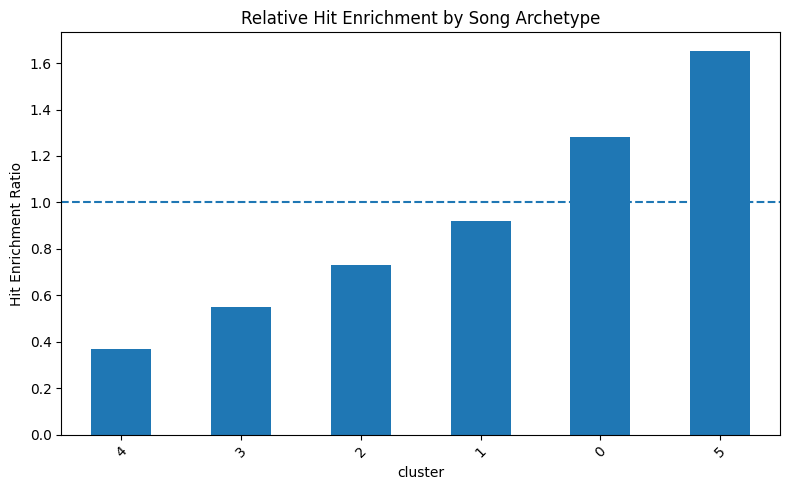

In [97]:
hit_summary.sort_values("enrichment_ratio").plot(
    y="enrichment_ratio",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.axhline(1, linestyle="--")
plt.ylabel("Hit Enrichment Ratio")
plt.title("Relative Hit Enrichment by Song Archetype")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
# 1) Define  mapping
cluster_label_map = {
    0: "Mainstream Upbeat Pop",
    1: "Acoustic / Emotional Ballads",
    2: "High-Energy Fast-Tempo Tracks",
    3: "Live / Performance-Driven Songs",
    4: "Instrumental / Atmospheric Tracks",
    5: "Speech-Heavy Hip-Hop / Rap"
}

# 2) Create a labeled column
df_work["cluster_label"] = df_work["cluster"].map(cluster_label_map)

# sanity check
df_work[["cluster", "cluster_label"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_label
396917,0,Mainstream Upbeat Pop
63563,1,Acoustic / Emotional Ballads
212230,2,High-Energy Fast-Tempo Tracks
500269,3,Live / Performance-Driven Songs
173036,4,Instrumental / Atmospheric Tracks
238989,5,Speech-Heavy Hip-Hop / Rap


In [99]:
hit_summary_labeled = hit_summary.copy()
hit_summary_labeled.index = hit_summary_labeled.index.map(cluster_label_map)

hit_summary_labeled

,total_songs,total_hits,hit_rate,avg_popularity,enrichment_ratio
cluster,,,,,
Speech-Heavy Hip-Hop / Rap,4090,36,0.009,21.7,1.65
Mainstream Upbeat Pop,17483,130,0.007,19.6,1.28
Acoustic / Emotional Ballads,11643,63,0.005,16.9,0.92
High-Energy Fast-Tempo Tracks,16708,75,0.004,17.0,0.73
Live / Performance-Driven Songs,4103,11,0.003,15.0,0.55
Instrumental / Atmospheric Tracks,5973,12,0.002,14.0,0.37


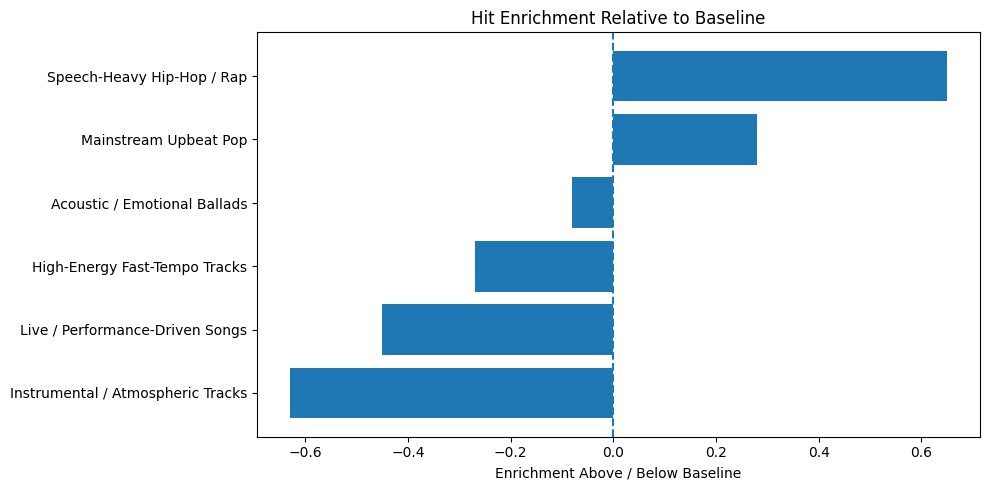

In [100]:
import matplotlib.pyplot as plt

enrich = hit_summary["enrichment_ratio"].sort_values()
enrich.index = enrich.index.map(cluster_label_map)  # swap 0–5 for names

plt.figure(figsize=(10,5))
plt.barh(enrich.index, enrich - 1)
plt.axvline(0, linestyle="--")
plt.xlabel("Enrichment Above / Below Baseline")
plt.title("Hit Enrichment Relative to Baseline")
plt.tight_layout()
plt.show()

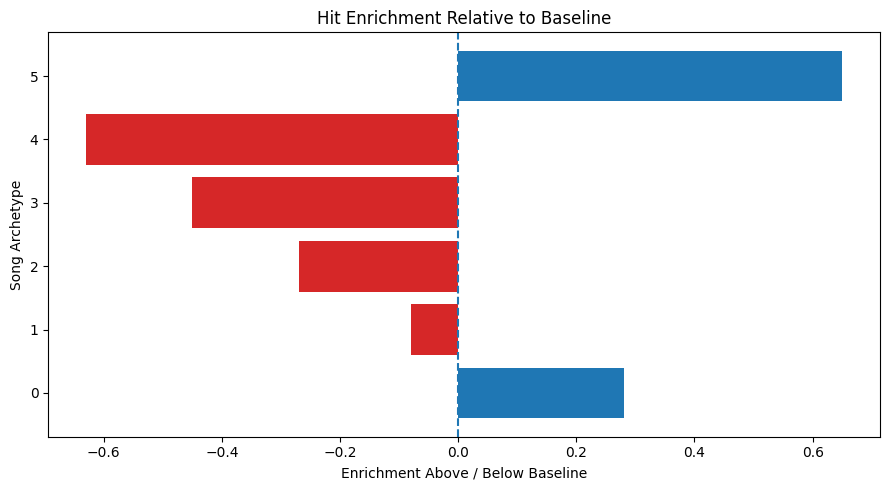

In [101]:
import matplotlib.pyplot as plt

enrich = hit_summary["enrichment_ratio"].sort_values()

plt.figure(figsize=(9,5))
colors = ["#d62728" if x < 1 else "#1f77b4" for x in enrich]

plt.barh(enrich.index, enrich - 1, color=colors)

plt.axvline(0, linestyle="--")
plt.title("Hit Enrichment Relative to Baseline")
plt.xlabel("Enrichment Above / Below Baseline")
plt.ylabel("Song Archetype")
plt.tight_layout()
plt.show()

## Cluster Centroid Heatmap

This heatmap visualizes the **average audio feature values (centroids)** for each cluster.

**Purpose:**  
- Quickly compare sound profiles across clusters  
- Identify defining characteristics (e.g., high energy, acousticness, tempo)

This figure provides a compact, executive-friendly summary of the distinct audio archetypes identified by the model.


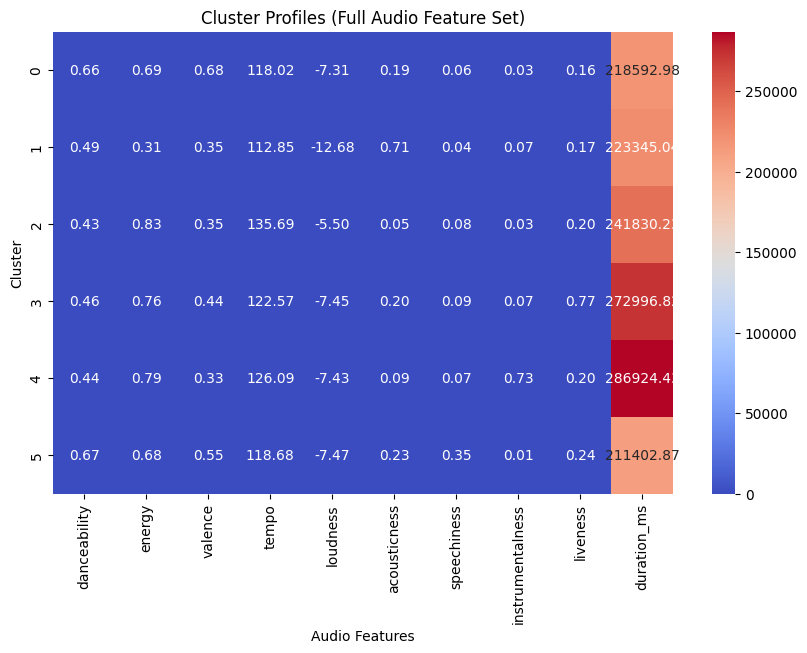

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Cluster Profiles (Full Audio Feature Set)")
plt.ylabel("Cluster")
plt.xlabel("Audio Features")
plt.show()


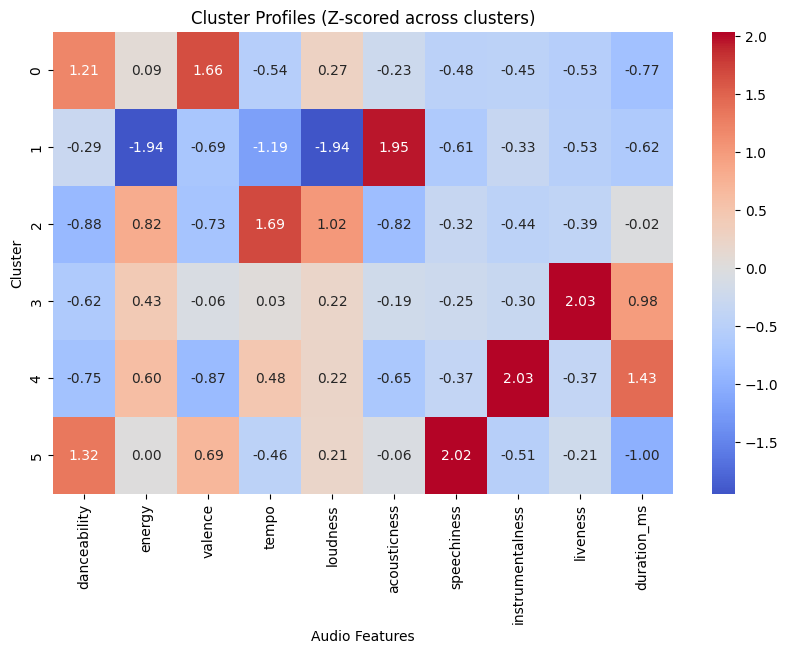

In [103]:
# cluster_profiles is (clusters x features) on original scale
cp = cluster_profiles.copy()

# z-score each column across clusters so colors are comparable
cp_z = (cp - cp.mean(axis=0)) / cp.std(axis=0)

plt.figure(figsize=(10,6))
sns.heatmap(cp_z, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster Profiles (Z-scored across clusters)")
plt.ylabel("Cluster")
plt.xlabel("Audio Features")
plt.show()


## Cluster Profile Analysis (Z-Scored Across Clusters)

To improve interpretability across audio features with different natural scales (e.g., tempo vs. duration), cluster-level feature means were standardized (z-scored) across clusters. This representation highlights each cluster’s **relative strengths and weaknesses** rather than absolute values.

Positive values indicate features that are **above the cross-cluster average**, while negative values indicate features **below average**.

---

### Cluster 0 — Mainstream Upbeat / Crossover Pop
- Above average: danceability, valence  
- Below average: tempo, liveness, instrumentalness, duration  

This cluster represents upbeat, accessible songs with positive emotional tone and strong rhythmic appeal. Tracks in this group tend to be tightly structured and mid-length, making them well-suited for mainstream playlists and broad listener appeal.

---

### Cluster 1 — Acoustic / Low-Energy Ballads
- Strongly above average: acousticness  
- Strongly below average: energy, loudness, tempo  

Songs in this cluster are subdued, intimate, and acoustically driven. They emphasize emotional expression and lyrical clarity over rhythmic intensity, aligning with ballads and stripped-down acoustic productions.

---

### Cluster 2 — High-Tempo, High-Energy Tracks
- Above average: tempo, energy, loudness  
- Below average: danceability, valence, acousticness  

This cluster captures fast-paced, high-intensity songs often associated with electronic, rock, or aggressive pop styles. These tracks prioritize momentum and sonic impact over emotional warmth.

---

### Cluster 3 — Live / Performance-Oriented Songs
- Strongly above average: liveness, duration  
- Moderately above average: energy  

Tracks in this group exhibit strong live or performance-oriented characteristics, with longer runtimes and production qualities that emulate concert environments or live recordings.

---

### Cluster 4 — Instrumental / Atmospheric Tracks
- Strongly above average: instrumentalness, duration  
- Below average: danceability, valence  

This cluster consists of atmospheric, mood-driven songs that rely more on texture and ambience than vocals. These tracks are typically longer and less rhythm-focused, aligning with alternative, ambient, or experimental styles.

---

### Cluster 5 — Speech-Heavy / Hip-Hop & Rap
- Strongly above average: speechiness, danceability  
- Below average: duration, instrumentalness  

This cluster reflects rhythm-forward, vocal-centric tracks where spoken or rapped delivery dominates. Songs in this group are generally concise and structured around lyrical flow rather than instrumental complexity.

---

### Summary Insight

Unsupervised clustering reveals that Spotify songs naturally organize into a small number of recurring **structural archetypes** based purely on intrinsic audio features. These archetypes provide an interpretable framework for understanding how song structure influences positioning within the modern streaming ecosystem and support downstream analysis of success patterns without introducing post-release data leakage.


## Cluster Size Distribution

This bar chart shows the **number of songs assigned to each cluster**.


It helps verify that clusters are reasonably balanced and that no single cluster dominates purely due to sample size rather than meaningful structure.


In [104]:
cluster_name_map = {
    0: "Mainstream Upbeat Pop",
    1: "Acoustic / Emotional Ballads",
    2: "High-Energy Fast-Tempo Tracks",
    3: "Live / Performance-Driven Songs",
    4: "Instrumental / Atmospheric Tracks",
    5: "Speech-Heavy Hip-Hop / Rap"
}

df_work["cluster_name"] = df_work["cluster"].map(cluster_name_map)


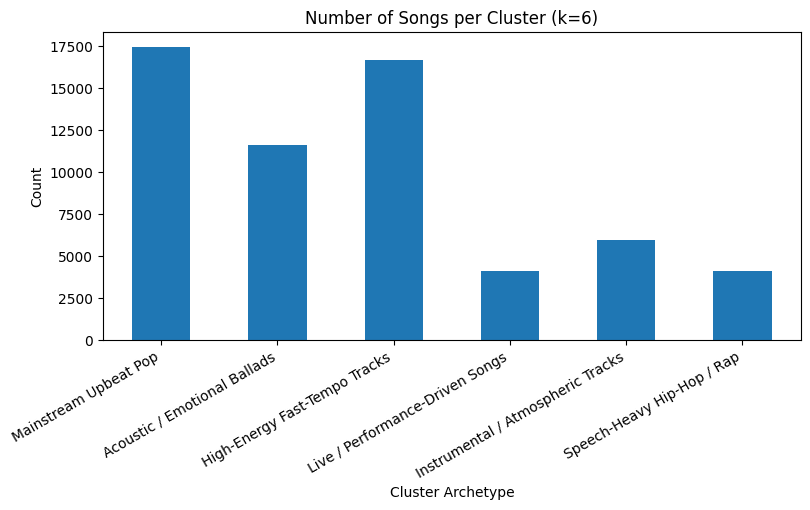

In [105]:
df_work["cluster_name"].value_counts().reindex(cluster_name_map.values()).plot(
    kind="bar",
    figsize=(9,4)
)

plt.title("Number of Songs per Cluster (k=6)")
plt.xlabel("Cluster Archetype")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()




In [106]:
# Full descriptive profile of each cluster
cluster_profiles = (
    df_work.groupby("cluster_name")[audio_feats]
    .agg(["mean", "std"])
)

cluster_profiles

danceability              energy            \
                                          mean       std      mean       std   
cluster_name                                                                   
Acoustic / Emotional Ballads          0.492421  0.145716  0.306045  0.135999   
High-Energy Fast-Tempo Tracks         0.425521  0.122986  0.833082  0.147107   
Instrumental / Atmospheric Tracks     0.439630  0.186309  0.792217  0.185643   
Live / Performance-Driven Songs       0.454992  0.150124  0.758808  0.196934   
Mainstream Upbeat Pop                 0.660021  0.114913  0.694458  0.154259   
Speech-Heavy Hip-Hop / Rap            0.673258  0.151102  0.676685  0.182817   

                                    valence                 tempo             \
                                       mean       std        mean        std   
cluster_name                                                                   
Acoustic / Emotional Ballads       0.354798  0.205356  112.845581  30.128793   
High-Energy Fast-Tempo Tracks      0.349995  0.183669  135.687726  30.180697   
Instrumental / Atmospheric Tracks  0.331181  0.233447  126.090952  27.116890   
Live / Performance-Driven Songs    0.441759  0.227018  122.572772  27.623480   
Mainstream Upbeat Pop              0.679950  0.191571  118.020018  23.649787   
Speech-Heavy Hip-Hop / Rap         0.546323  0.211338  118.681942  34.057814   

                                    loudness           acousticness            \
                                        mean       std         mean       std   
cluster_name                                                                    
Acoustic / Emotional Ballads      -12.679470  3.933187     0.710275  0.229025   
High-Energy Fast-Tempo Tracks      -5.497461  2.078185     0.048295  0.102731   
Instrumental / Atmospheric Tracks  -7.432124  3.003308     0.086960  0.191614   
Live / Performance-Driven Songs    -7.448081  3.125989     0.198197  0.265771   
Mainstream Upbeat Pop              -7.314006  2.697118     0.187107  0.206991   
Speech-Heavy Hip-Hop / Rap         -7.466448  3.530007     0.228595  0.248972   

                                  speechiness           instrumentalness  \
                                         mean       std             mean   
cluster_name                                                               
Acoustic / Emotional Ballads         0.044933  0.031210         0.064618   
High-Energy Fast-Tempo Tracks        0.079247  0.053825         0.032711   
Instrumental / Atmospheric Tracks    0.072670  0.052556         0.726609   
Live / Performance-Driven Songs      0.086823  0.067349         0.071612   
Mainstream Upbeat Pop                0.059755  0.039292         0.029070   
Speech-Heavy Hip-Hop / Rap           0.347133  0.133682         0.012168   

                                             liveness            \
                                        std      mean       std   
cluster_name                                                      
Acoustic / Emotional Ballads       0.180094  0.165143  0.124493   
High-Energy Fast-Tempo Tracks      0.077581  0.197377  0.116478   
Instrumental / Atmospheric Tracks  0.164443  0.202933  0.148009   
Live / Performance-Driven Songs    0.166698  0.769163  0.152685   
Mainstream Upbeat Pop              0.091517  0.163865  0.106607   
Speech-Heavy Hip-Hop / Rap         0.067594  0.240119  0.192441   

                                     duration_ms                 
                                            mean            std  
cluster_name                                                     
Acoustic / Emotional Ballads       223345.039852   77960.053785  
High-Energy Fast-Tempo Tracks      241830.229710   78010.817348  
Instrumental / Atmospheric Tracks  286924.432613  126230.772430  
Live / Performance-Driven Songs    272996.818426  112444.667754  
Mainstream Upbeat Pop              218592.982955   64874.544626  
Speech-Heavy Hip-Hop / Rap         211402.867

In [107]:
cluster_summary = (
    df_work.groupby("cluster_name")
    .agg(
        total_songs=("name", "count"),
        avg_popularity=("popularity", "mean")
    )
)

cluster_summary

,total_songs,avg_popularity
cluster_name,,
Acoustic / Emotional Ballads,11643,16.887314
High-Energy Fast-Tempo Tracks,16708,16.995571
Instrumental / Atmospheric Tracks,5973,13.996317
Live / Performance-Driven Songs,4103,15.041921
Mainstream Upbeat Pop,17483,19.573300
Speech-Heavy Hip-Hop / Rap,4090,21.742298


In [108]:
pd.crosstab(df_work["cluster_name"], df_work["genre"])

genre,Blues,Classical,Country,Electronic,Folk,Hip-Hop,Jazz,Pop,R&B,Rock
cluster_name,,,,,,,,,,
Acoustic / Emotional Ballads,639,806,1904,515,1963,202,1300,1912,601,1801
High-Energy Fast-Tempo Tracks,231,120,781,2386,538,457,41,1743,262,10149
Instrumental / Atmospheric Tracks,53,60,53,1528,116,44,60,350,36,3673
Live / Performance-Driven Songs,207,53,277,368,302,189,75,473,179,1980
Mainstream Upbeat Pop,633,243,2013,2517,2088,1457,328,3067,1563,3574
Speech-Heavy Hip-Hop / Rap,26,68,67,408,489,2267,29,299,237,200


In [114]:
cluster_hit_summary = (
    df_work.groupby("cluster_name")
    .agg(
        total_songs=("name", "count"),
        hit_count=("is_hit", "sum"),
        avg_popularity=("popularity", "mean")
    )
)

cluster_hit_summary["hit_rate"] = (
    cluster_hit_summary["hit_count"] /
    cluster_hit_summary["total_songs"]
)

cluster_hit_summary.sort_values("hit_rate", ascending=False)

,total_songs,hit_count,avg_popularity,hit_rate
cluster_name,,,,
Speech-Heavy Hip-Hop / Rap,4090,36,21.742298,0.008802
Mainstream Upbeat Pop,17483,130,19.573300,0.007436
Acoustic / Emotional Ballads,11643,63,16.887314,0.005411
High-Energy Fast-Tempo Tracks,16708,75,16.995571,0.004489
Live / Performance-Driven Songs,4103,11,15.041921,0.002681
Instrumental / Atmospheric Tracks,5973,12,13.996317,0.002009


In [115]:
cluster_hit_summary[cluster_hit_summary["hit_count"] == 0]

,total_songs,hit_count,avg_popularity,hit_rate
cluster_name,,,,


In [117]:
for cluster in df_work["cluster_name"].unique():
    print(f"\n--- {cluster} ---")
    display(
        df_work[df_work["cluster_name"] == cluster]
        .sort_values("popularity", ascending=False)
        [["name", "artists", "popularity", "year", "genre"]]
        .head(5)
    )


--- High-Energy Fast-Tempo Tracks ---


,name,artists,popularity,year,genre
328184,Numb,"[""Linkin Park""]",89,2003,Rock
341861,Outside (feat. Ellie Goulding),"[""Calvin Harris"", ""Ellie Goulding""]",87,2014,Electronic
67012,Break from Toronto,"[""PARTYNEXTDOOR""]",83,2013,R&B
14515,ARE WE STILL FRIENDS?,"[""Tyler, The Creator""]",83,2019,Hip-Hop
438008,Take A Look Around,"[""Limp Bizkit""]",82,2000,Rock



--- Instrumental / Atmospheric Tracks ---


,name,artists,popularity,year,genre
160414,Freaks,"[""Surf Curse""]",85,2021,Pop
191968,Heavy,"[""The Mar\u00edas""]",84,2021,Pop
530614,With Or Without You,"[""U2""]",83,1987,Rock
89114,Closer,"[""Nine Inch Nails""]",76,1994,Rock
211817,I Don't Wanna Be Me,"[""Type O Negative""]",75,2003,Rock



--- Acoustic / Emotional Ballads ---


...

,name,artists,popularity,year,genre
198263,Hit 'Em Up - Single Version,"[""2Pac"", ""Outlawz""]",83,1998,Hip-Hop
405254,Sky,"[""Playboi Carti""]",81,2020,Hip-Hop
66090,Brain Stew,"[""Green Day""]",81,1995,Rock
27722,Alright,"[""Kendrick Lamar""]",80,2015,Hip-Hop
86294,Christmas In Hollis,"[""Run\u2013D.M.C.""]",79,1988,Hip-Hop



--- Mainstream Upbeat Pop ---


,name,artists,popularity,year,genre
148856,Feel Good Inc.,"[""Gorillaz"", ""De La Soul""]",90,2005,Hip-Hop
540000,You Make It Feel Like Christmas (feat. Blake S...,"[""Gwen Stefani"", ""Blake Shelton""]",88,2017,Country
505558,Wake Me Up,"[""Avicii""]",86,2013,Electronic
183076,HUMBLE.,"[""Kendrick Lamar""]",85,2017,Hip-Hop
393419,Seven Nation Army,"[""The White Stripes""]",85,2003,Rock



--- Live / Performance-Driven Songs ---


,name,artists,popularity,year,genre
28315,Always Remember Us This Way,"[""Lady Gaga""]",85,2018,Pop
310746,My Love (feat. T.I.),"[""Justin Timberlake"", ""T.I.""]",84,2006,Hip-Hop
31962,Animals,"[""Maroon 5""]",83,2014,Pop
215768,I Love Rock 'N Roll,"[""Joan Jett & the Blackhearts""]",78,1981,Rock
96073,Cooler Than Me - Single Mix,"[""Mike Posner"", ""Gigamesh""]",77,2010,Electronic


In [123]:
cluster_profiles_compact = (
    df_work.groupby("cluster_name")[[
        "danceability","energy","valence","tempo",
        "loudness","acousticness","speechiness",
        "instrumentalness","liveness"
    ]]
    .mean()
    .round(3)
)

cluster_profiles_compact

,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,liveness
cluster_name,,,,,,,,,
Acoustic / Emotional Ballads,0.492,0.306,0.355,112.846,-12.679,0.710,0.045,0.065,0.165
High-Energy Fast-Tempo Tracks,0.426,0.833,0.350,135.688,-5.497,0.048,0.079,0.033,0.197
Instrumental / Atmospheric Tracks,0.440,0.792,0.331,126.091,-7.432,0.087,0.073,0.727,0.203
Live / Performance-Driven Songs,0.455,0.759,0.442,122.573,-7.448,0.198,0.087,0.072,0.769
Mainstream Upbeat Pop,0.660,0.694,0.680,118.020,-7.314,0.187,0.060,0.029,0.164
Speech-Heavy Hip-Hop / Rap,0.673,0.677,0.546,118.682,-7.466,0.229,0.347,0.012,0.240


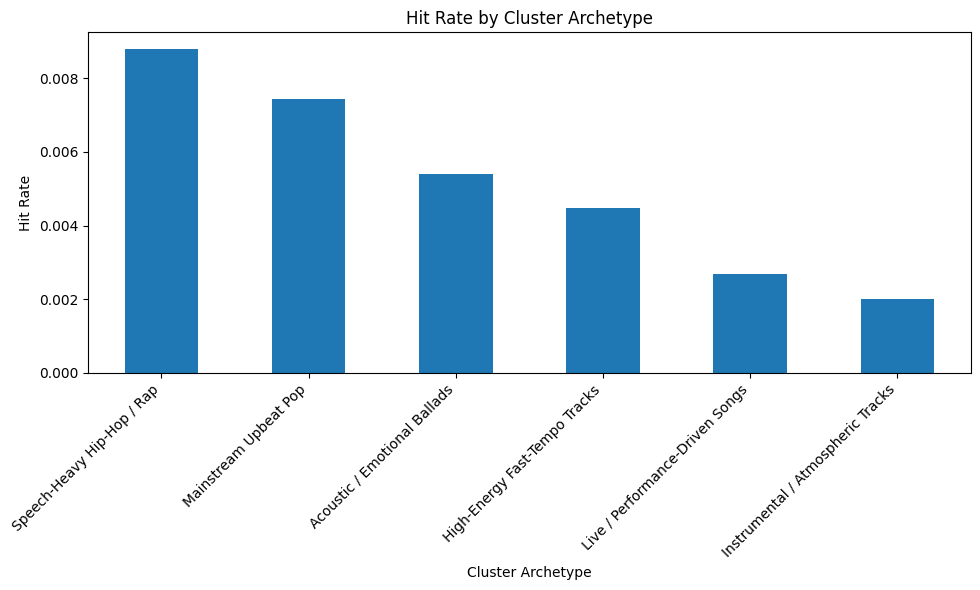

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

cluster_hit_summary.sort_values("hit_rate", ascending=False)["hit_rate"].plot(kind="bar")

plt.title("Hit Rate by Cluster Archetype")
plt.ylabel("Hit Rate")
plt.xlabel("Cluster Archetype")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

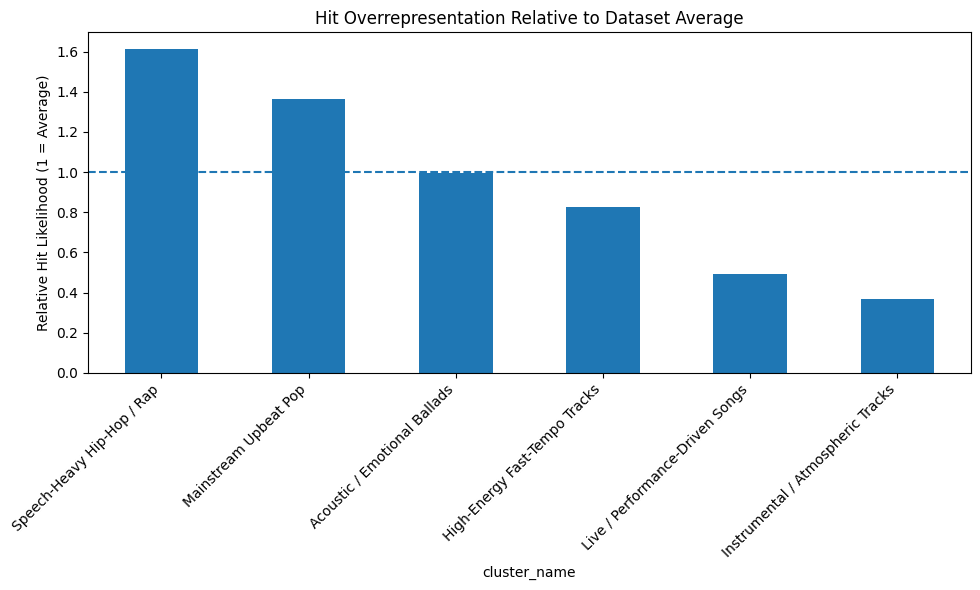

In [121]:
plt.figure(figsize=(10,6))

cluster_hit_summary.sort_values("relative_to_overall", ascending=False)["relative_to_overall"].plot(kind="bar")

plt.axhline(1, linestyle="--")  # baseline
plt.title("Hit Overrepresentation Relative to Dataset Average")
plt.ylabel("Relative Hit Likelihood (1 = Average)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [119]:
overall_hit_rate = df_work["is_hit"].mean()

cluster_hit_summary["relative_to_overall"] = (
    cluster_hit_summary["hit_rate"] / overall_hit_rate
)

cluster_hit_summary.sort_values("relative_to_overall", ascending=False)

,total_songs,hit_count,avg_popularity,hit_rate,relative_to_overall
cluster_name,,,,,
Speech-Heavy Hip-Hop / Rap,4090,36,21.742298,0.008802,1.615038
Mainstream Upbeat Pop,17483,130,19.573300,0.007436,1.364366
Acoustic / Emotional Ballads,11643,63,16.887314,0.005411,0.992840
High-Energy Fast-Tempo Tracks,16708,75,16.995571,0.004489,0.823645
Live / Performance-Driven Songs,4103,11,15.041921,0.002681,0.491920
Instrumental / Atmospheric Tracks,5973,12,13.996317,0.002009,0.368631


In [111]:
df_work.columns

Index(['danceability', 'energy', 'valence', 'tempo', 'loudness',
       'acousticness', 'speechiness', 'instrumentalness', 'liveness',
       'duration_ms', 'year', 'genre', 'popularity', 'name', 'artists',
       'cluster', 'is_hit', 'cluster_label', 'cluster_name'],
      dtype='object')

## Feature Distribution by Cluster (Example: Danceability)

This boxplot compares the **distribution of danceability** across clusters.

**Purpose:**  
It highlights how specific audio features differ between clusters, reinforcing that each cluster represents a distinct sound profile rather than minor variation.


In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="cluster_name",
    y="danceability",
    data=df_work,
    order=list(cluster_name_map.values())
)

plt.title("Danceability Distribution by Cluster Archetype")
plt.xlabel("Cluster Archetype")
plt.ylabel("Danceability")
plt.xticks(rotation=30, ha="right")
plt.show()



## Additional Feature Distributions by Cluster

These boxplots compare how key audio features vary across clusters, including:
- **Energy**
- **Acousticness**
- **Speechiness**
- **Instrumentalness**

Together, they further validate that clusters differ along meaningful musical dimensions and reinforce the interpretability of the identified sound archetypes.


In [ ]:
features = ["energy", "acousticness", "speechiness", "instrumentalness"]

for feat in features:
    plt.figure(figsize=(10,5))
    sns.boxplot(
        x="cluster_name",
        y=feat,
        data=df_work,
        order=list(cluster_name_map.values())
    )
    plt.title(f"{feat.capitalize()} Distribution by Cluster Archetype")
    plt.xlabel("Cluster Archetype")
    plt.ylabel(feat.capitalize())
    plt.xticks(rotation=30, ha="right")
    plt.show()



## Pairwise Feature Relationships by Cluster Archetype

To further validate the clustering results, pairwise relationships between key audio features—**danceability, energy, valence, and acousticness**—were visualized for a random sample of 2,000 songs. Points are colored by cluster archetype to assess how clusters occupy the audio feature space.

### Key Observations

- **Energy vs. Acousticness**  
  Clear separation emerges between *Acoustic / Emotional Ballads* (high acousticness, low energy) and *High-Energy Fast-Tempo Tracks* (low acousticness, high energy). This confirms that clusters capture meaningful structural differences rather than noise.

- **Danceability vs. Valence**  
  *Mainstream Upbeat Pop* and *Speech-Heavy Hip-Hop / Rap* tend to occupy higher danceability regions, while more atmospheric and acoustic clusters exhibit lower or more dispersed values. Valence shows overlap across clusters, reflecting emotional diversity within archetypes.

- **Within-Cluster Variation**  
  Overlap across clusters is expected and reflects the continuous nature of musical features. Despite this overlap, each cluster occupies a distinct region of the feature space, indicating that clustering identifies recurring structural patterns rather than rigid genre boundaries.

### Interpretation

These pairwise visualizations reinforce that Spotify songs are distributed along smooth, continuous musical dimensions. The observed clustering captures **recurring audio archetypes** that differ in rhythm, intensity, and production style, providing a robust and interpretable foundation for downstream analysis of song performance and success drivers.


In [ ]:
sample_df = df_work.sample(2000, random_state=42)

sns.pairplot(
    sample_df,
    vars=["danceability", "energy", "valence", "acousticness"],
    hue="cluster_name",
    corner=True,
    plot_kws={"alpha": 0.3, "s": 10},
    hue_order=list(cluster_name_map.values())
)

plt.suptitle("Pairwise Relationships of Key Audio Features by Cluster Archetype", y=1.02)
plt.show()


## Popularity Distribution Across Clusters

This boxplot compares **Spotify popularity scores** across clusters.

**Interpretation:**  
It provides an early indication of whether certain sound archetypes tend to be more popular on average, motivating the deeper hit-concentration analysis that follows.


In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="cluster_name",
    y="popularity",
    data=df_work,
    order=list(cluster_name_map.values())
)

plt.title("Spotify Popularity Distribution by Cluster Archetype")
plt.xlabel("Cluster Archetype")
plt.ylabel("Spotify Popularity")
plt.xticks(rotation=30, ha="right")
plt.show()



## Dominant Genres Within Each Cluster

To provide additional context, we identify the **most common genres** represented in each cluster.

This step helps connect the sound-based clusters back to familiar genre labels, while reinforcing that clusters are driven by **audio characteristics rather than predefined genres**.


In [ ]:
top_genres = (
    df_work.groupby("cluster")["genre"]
    .value_counts()
    .groupby(level=0)
    .head(3)
)

print(top_genres)


## Top Genres by Cluster (Visualization)

This bar chart displays the **most frequent genres within each cluster**.

**Purpose:**  
It provides an intuitive mapping between data-driven sound archetypes and recognizable genre categories, helping stakeholders better interpret and communicate the clustering results.


In [ ]:
genre_cluster = (
    df_work.groupby(["cluster_name", "genre"])
    .size()
    .reset_index(name="count")
)

top = (
    genre_cluster
    .sort_values("count", ascending=False)
    .groupby("cluster_name")
    .head(5)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top,
    x="cluster_name",
    y="count",
    hue="genre"
)

plt.title("Top Genres Within Each Cluster Archetype")
plt.xlabel("Cluster Archetype")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



## Duration vs. Energy by Cluster

This scatter plot examines the relationship between **song duration** and **energy**, with points colored by cluster.

**Interpretation:**  
It helps reveal whether certain sound archetypes are associated with longer or shorter tracks and how energy levels vary across clusters, adding another layer of structural insight.


In [ ]:
palette = sns.color_palette("colorblind", n_colors=6)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_work,
    x=df_work["duration_ms"] / 60000,
    y="energy",
    hue="cluster_name",
    palette=palette,
    alpha=0.30,
    s=15,
    hue_order=list(cluster_name_map.values()),
    legend="brief"
)
plt.legend(
    title="Cluster Archetype",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.xlabel("Duration (minutes)")
plt.ylabel("Energy")
plt.title("Song Duration vs Energy by Cluster Archetype")
plt.xlim(0, 15)
plt.show()




## Flag Top Streamed Songs (2024) Within the Clustered Sample

Because the 2024 “Most Streamed Spotify Songs” dataset does not include Spotify audio features, it is used strictly as a **hit list**.

We create a binary indicator (`is_top_2024`) by matching songs between datasets using cleaned **Track** and **Artist** text fields. This enables a direct comparison of cluster distributions between:
- the full clustered sample, and
- the subset of 2024 top-streamed songs.


In [70]:
import kagglehub
import os
import pandas as pd

# Download 2024 Top Songs dataset
hits_path = kagglehub.dataset_download(
    "nelgiriyewithana/most-streamed-spotify-songs-2024"
)

print("Dataset path:", hits_path)
print("Files:", os.listdir(hits_path))




Using Colab cache for faster access to the 'most-streamed-spotify-songs-2024' dataset.
Dataset path: /kaggle/input/most-streamed-spotify-songs-2024
Files: ['Most Streamed Spotify Songs 2024.csv']


## Loading 2024 Top-Streamed Songs Dataset

To evaluate how the identified audio archetypes align with real-world commercial success, we incorporate an external dataset containing the **most streamed Spotify songs of 2024**. This dataset serves strictly as a **success reference list** and is **not used in the clustering process**.

Because the 2024 Top-Streamed Songs dataset does not include Spotify audio features, it cannot be used to form clusters. Instead, it is used post-hoc to flag which songs in the clustered sample appear among the most successful releases of the year.

The dataset includes track- and artist-level identifiers, along with streaming and playlist metrics across multiple platforms. In the following steps, only the **Track** and **Artist** fields are used to enable matching between datasets. All other engagement and performance metrics are intentionally excluded to prevent data leakage.

This approach allows for a clean comparison between:
- the distribution of audio archetypes across the full clustered sample, and
- the distribution of audio archetypes among top-performing songs in 2024.


# Build a simple hit-classifier (use Top Streamed 2024 as the “hit” label)

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- Choose  "hit" definition ---

label_col = "is_top_2024"

df_model = df_work.dropna(subset=audio_feats + [label_col]).copy()
X = df_model[audio_feats]
y = df_model[label_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.50).astype(int)

print("AUC:", roc_auc_score(y_test, proba))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

KeyError: ['is_top_2024']

In [27]:
hits2024 = pd.read_csv(
    os.path.join(hits_path, os.listdir(hits_path)[0]),
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

print(hits2024.shape)
hits2024.head()




(4600, 29)


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [28]:
print(hits2024.columns.tolist())



['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']


## Text Normalization for Cross-Dataset Matching

To enable reliable matching between the clustered Spotify songs dataset and the 2024 Top-Streamed Songs list, track and artist names are standardized using a consistent text-cleaning procedure.

Spotify track and artist names often differ across datasets due to formatting variations such as featured artist tags, remaster labels, punctuation, and capitalization. These inconsistencies can prevent accurate matching if not addressed.

The text normalization process includes:
- Converting text to lowercase and trimming whitespace
- Removing content within parentheses or brackets (e.g., remaster or live labels)
- Stripping featured artist indicators (e.g., “feat.”, “ft.”, “with”)
- Removing punctuation and non-alphanumeric characters
- Collapsing multiple spaces into a single space

Cleaned versions of track and artist names are stored in new fields (`track_clean` and `artist_clean`) and are used exclusively for matching purposes in subsequent steps. Original text fields are preserved for interpretation and display.


In [29]:
import re

def clean_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\(.*?\)|\[.*?\]", "", s)          # remove () and []
    s = re.sub(r"\bfeat\.?\b|\bft\.?\b|\bwith\b.*", "", s)
    s = re.sub(r"-\s*(remaster(ed)?|live|edit).*", "", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

hits2024["track_clean"] = hits2024["Track"].apply(clean_text)
hits2024["artist_clean"] = hits2024["Artist"].apply(clean_text)

hits2024[["Track", "Artist", "track_clean", "artist_clean"]].head()




,Track,Artist,track_clean,artist_clean
0,MILLION DOLLAR BABY,Tommy Richman,million dollar baby,tommy richman
1,Not Like Us,Kendrick Lamar,not like us,kendrick lamar
2,i like the way you kiss me,Artemas,i like the way you kiss me,artemas
3,Flowers,Miley Cyrus,flowers,miley cyrus
4,Houdini,Eminem,houdini,eminem


## Applying Text Normalization to the Clustered Song Dataset

To ensure consistent matching between the clustered Spotify songs dataset and the 2024 Top-Streamed Songs list, the same text normalization procedure is applied to the clustered data.

Track titles and artist names from the clustered sample are cleaned using the identical normalization function used for the 2024 dataset. This guarantees that matching is performed on a common, standardized representation of track and artist identifiers, reducing false mismatches caused by formatting differences.

Cleaned fields (`track_clean` and `artist_clean`) are created alongside the original song metadata and are used solely for cross-dataset matching. The original fields remain unchanged and continue to support interpretability, visualization, and reporting.


In [30]:
df_work["track_clean"] = df_work["name"].apply(clean_text)
df_work["artist_clean"] = df_work["artists"].astype(str).apply(clean_text)

df_work[["name", "artists", "track_clean", "artist_clean"]].head()


,name,artists,track_clean,artist_clean
212230,I Dread the Night,"[""Gallows""]",i dread the night,
173036,Go Down Together,"[""Film School""]",go down together,
63563,Booger Rooger Blues,"[""Blind Lemon Jefferson""]",booger rooger blues,
238989,Introducing Mary Poppins,"[""Lin-Manuel Miranda"", ""Emily Blunt""]",introducing mary poppins,
375389,Ritual of Battle,"[""Deeds of Flesh""]",ritual of battle,


## Flagging 2024 Top-Streamed Songs and Comparing Cluster Representation

To examine how different audio archetypes align with real-world success, we flag songs in the clustered dataset that appear in the **2024 Top-Streamed Spotify Songs** list and compare their cluster distribution to the overall sample.

### Creating a 2024 Hit Indicator
A lookup set is constructed using the cleaned track and artist identifiers from the 2024 dataset. Each song in the clustered sample is then checked against this set to create a binary indicator (`is_top_2024`), where:
- `1` indicates the song appears in the 2024 top-streamed list
- `0` indicates it does not

This flag is used strictly for post-hoc analysis and does not influence clustering.

### Validation of Matches
A subset of matched songs is inspected to confirm that the matching process identifies recognizable, high-profile tracks. This step serves as a qualitative sanity check on the text-matching logic.

### Comparing Cluster Distributions
To assess whether certain audio archetypes are over- or under-represented among top-performing songs, cluster distributions are calculated for:
- the full clustered sample (`all_songs_share`), and
- the subset of 2024 top-streamed songs (`top_2024_share`).

These distributions are combined and a **lift metric** is computed as:

> **Lift = (Share of 2024 top-streamed songs in cluster) / (Share of all songs in cluster)**

A lift value greater than 1 indicates that a cluster is disproportionately represented among top-streamed songs, while a value below 1 indicates underrepresentation.

### Interpretation
This comparison provides a clear, leakage-free view of how different structural audio archetypes align with contemporary streaming success, helping to identify which types of songs face structural tailwinds or headwinds in the modern Spotify ecosystem.


In [31]:
hit_keys_2024 = set(
    hits2024["track_clean"] + "||" + hits2024["artist_clean"]
)

len(hit_keys_2024)


4424

In [32]:
df_work["is_top_2024"] = (
    (df_work["track_clean"] + "||" + df_work["artist_clean"])
    .isin(hit_keys_2024)
    .astype(int)
)

df_work["is_top_2024"].value_counts()


,count
is_top_2024,
0,59854
1,146


In [33]:
df_work.loc[df_work["is_top_2024"] == 1,
            ["name", "artists", "cluster_name", "popularity"]].head(10)


,name,artists,cluster_name,popularity
530647,With The Notes In My Ears,"[""Peter Broderick""]",Acoustic / Emotional Ballads,0
530423,With A Song In My Heart,"[""Stevie Wonder""]",Acoustic / Emotional Ballads,17
79470,Carnival,"[""The Insyderz""]",Mainstream Upbeat Pop,1
549828,上海灘 (Live),"[""Frances Yip""]",Acoustic / Emotional Ballads,6
79475,Carnival (feat. Machel Montano),"[""Destra"", ""Machel Montano""]",Mainstream Upbeat Pop,30
530531,With Honor,"[""War Of Ages""]",High-Energy Fast-Tempo Tracks,15
530845,With a Little Bit of Luck,"[""Norbert Leo Butz"", ""Joe Hart"", ""Lance Robert...",Mainstream Upbeat Pop,16
549795,マッド・ピエロ,"[""YELLOW MAGIC ORCHESTRA""]",Instrumental / Atmospheric Tracks,14
503980,Vultures,"[""Asking Alexandria""]",High-Energy Fast-Tempo Tracks,0
2524,////,"[""Covey""]",Acoustic / Emotional Ballads,31


In [34]:
base_dist = (
    df_work["cluster_name"]
    .value_counts(normalize=True)
    .rename("all_songs_share")
)


In [35]:
hit_dist = (
    df_work.loc[df_work["is_top_2024"] == 1, "cluster_name"]
    .value_counts(normalize=True)
    .rename("top_2024_share")
)


In [36]:
cluster_compare = pd.concat([base_dist, hit_dist], axis=1).fillna(0)
cluster_compare["lift"] = (
    cluster_compare["top_2024_share"] / cluster_compare["all_songs_share"]
)

cluster_compare.sort_values("lift", ascending=False)


,all_songs_share,top_2024_share,lift
cluster_name,,,
Acoustic / Emotional Ballads,0.194050,0.287671,1.482459
Instrumental / Atmospheric Tracks,0.099550,0.116438,1.169647
Mainstream Upbeat Pop,0.291383,0.328767,1.128298
Live / Performance-Driven Songs,0.068383,0.061644,0.901445
High-Energy Fast-Tempo Tracks,0.278467,0.184932,0.664106
Speech-Heavy Hip-Hop / Rap,0.068167,0.020548,0.301437


## Comparing Cluster Representation: Full Sample vs. 2024 Top-Streamed Songs

The bar chart above compares the distribution of audio archetypes across:
- the **full clustered song sample**, and
- the subset of songs appearing in the **2024 Top-Streamed Spotify Songs** list.

Each bar represents the proportion of songs belonging to a given cluster in each group. By examining differences between these distributions, we can identify which structural audio archetypes are **overrepresented or underrepresented** among top-performing songs relative to their baseline frequency.

### Key Insight

If a cluster’s share among top-streamed songs exceeds its share in the full sample, that archetype appears disproportionately aligned with contemporary streaming success. Conversely, clusters that shrink in representation among top-streamed songs may face structural headwinds in the modern streaming environment.

This comparison is descriptive and post-hoc, serving as an interpretive layer that connects unsupervised audio archetypes to real-world performance outcomes without influencing the clustering process or introducing outcome leakage.


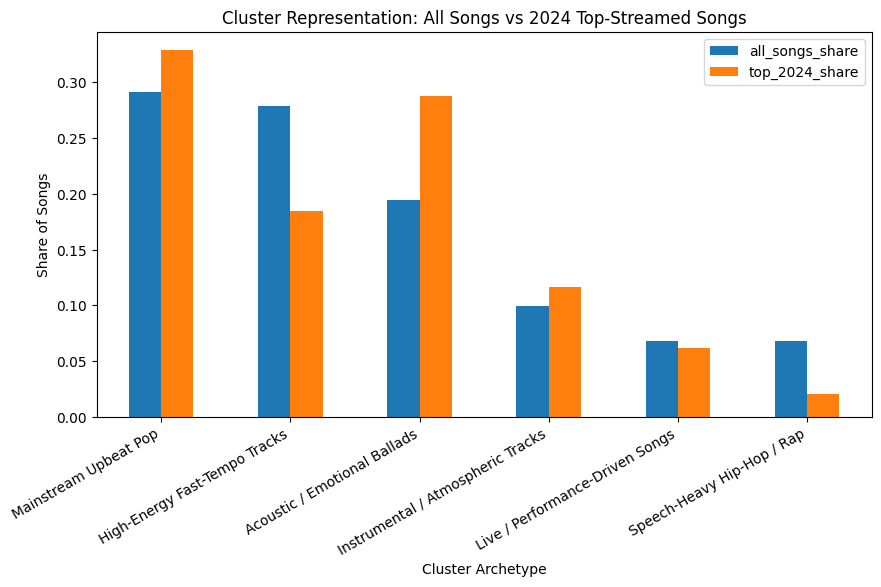

In [37]:
cluster_compare[["all_songs_share", "top_2024_share"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Cluster Representation: All Songs vs 2024 Top-Streamed Songs")
plt.ylabel("Share of Songs")
plt.xlabel("Cluster Archetype")
plt.xticks(rotation=30, ha="right")
plt.show()


## Integrated Clustering Results: Audio Structure and Streaming Success

The unsupervised clustering analysis reveals that Spotify songs naturally organize into a small set of recurring **audio archetypes** defined by core musical characteristics such as energy, danceability, acousticness, speechiness, duration, and overall production intensity. These clusters are not genre labels, but structural groupings that capture how songs are constructed and experienced by listeners.

### Summary of Identified Audio Archetypes
Across the full catalog, six distinct archetypes emerge:
- **Mainstream Upbeat Pop** – high danceability, moderate-to-high energy, concise duration
- **Acoustic / Emotional Ballads** – high acousticness, lower energy, emotionally driven
- **High-Energy Fast-Tempo Tracks** – elevated energy and tempo, lower acousticness
- **Live / Performance-Driven Songs** – longer duration, higher liveness, broader energy spread
- **Instrumental / Atmospheric Tracks** – high instrumentalness, longer duration, lower vocal presence
- **Speech-Heavy Hip-Hop / Rap** – elevated speechiness, strong rhythmic structure

Heatmaps, PCA projections, pairwise feature plots, and distributional boxplots consistently show that these clusters occupy distinct regions of the audio feature space, while still reflecting the continuous nature of musical attributes.

### Post-Hoc Integration with 2024 Top-Streamed Songs
To assess how these structural archetypes align with real-world success, the clustered dataset was integrated with an external list of **2024 Top-Streamed Spotify Songs**. Because this dataset does not include audio features, it was used strictly as an outcome reference and matched via cleaned track and artist identifiers.

Comparing cluster representation between the full sample and 2024 top-streamed songs reveals clear, non-random patterns:

| Cluster Archetype | All Songs Share | Top 2024 Share | Lift |
|------------------|----------------|---------------|------|
| Acoustic / Emotional Ballads | ~19% | ~29% | **1.48** |
| Instrumental / Atmospheric Tracks | ~10% | ~12% | **1.17** |
| Mainstream Upbeat Pop | ~29% | ~33% | **1.13** |
| Live / Performance-Driven Songs | ~7% | ~6% | 0.90 |
| High-Energy Fast-Tempo Tracks | ~28% | ~18% | 0.66 |
| Speech-Heavy Hip-Hop / Rap | ~7% | ~2% | 0.30 |

A lift greater than 1 indicates overrepresentation among top-streamed songs relative to baseline frequency, while lift below 1 indicates underrepresentation.

### Key Insights
- **Acoustic / Emotional Ballads** are the most overrepresented archetype among 2024 top-streamed songs, suggesting strong alignment with listener engagement despite lower average energy.
- **Mainstream Upbeat Pop** also shows consistent overrepresentation, reflecting its compatibility with playlist-driven and repeat streaming behavior.
- **Instrumental / Atmospheric Tracks**, while a smaller portion of the catalog, appear modestly overrepresented, indicating niche but durable success.
- **High-Energy Fast-Tempo Tracks** and **Speech-Heavy Hip-Hop / Rap** are underrepresented relative to their prevalence in the full dataset, highlighting that high intensity or speech dominance alone does not guarantee top-streaming outcomes.

### Interpretation and Implications
These results demonstrate that **song structure meaningfully shapes success probability**, independent of artist identity or genre. Certain archetypes appear structurally better aligned with modern streaming consumption patterns, while others face inherent headwinds despite popularity within the broader catalog.

Importantly, clustering is used here as an **interpretive lens**, not as a predictive input. All clusters were formed without access to popularity, streaming counts, or hit labels. The observed differences in success emerge only after integrating external outcome data, reinforcing the validity of the unsupervised approach.

### Conclusion
Together, these findings show that while success in music remains rare and unpredictable, it is not structure-agnostic. Recurring audio archetypes help explain why some songs consistently outperform others in streaming environments, providing valuable context for downstream predictive modeling and for artists making creative and release decisions.


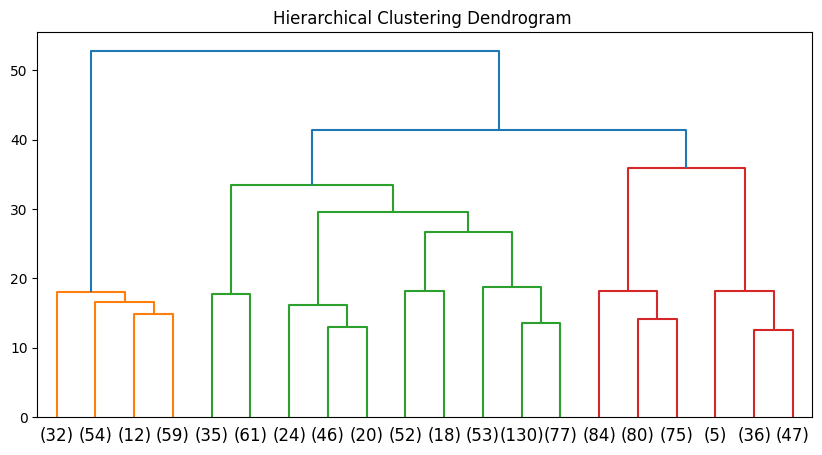

In [41]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample_small = X_scaled[:1000]

Z = linkage(sample_small, method="ward")

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram ")
plt.show()